#  Transaction Analysis for Market Expansion


In [1]:
import pandas as pd
import pyodbc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=DESKTOP-55JNORK\\SQLEXPRESS;"
    "Database=phonepe;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;")
cursor = conn.cursor()
print(" successfully")

 successfully


## Scenario

PhonePe wants to understand transaction performance across
different states and identify important regions for market
expansion.

This analysis focuses on transaction volume and value across
states.
## Objective

- Identify top-performing states.
- Compare transaction amounts across states.
- Understand transaction distribution.
- Identify potential markets for expansion.

### load data

In [4]:
query4 = """
select top 10 *
from aggregated_transaction"""

df4= pd.read_sql(query4, conn)
df4

C:\Users\Devendra\AppData\Local\Temp\ipykernel_50372\2090758528.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df4= pd.read_sql(query4, conn)


,States,Years,Quarter,Transaction_type,Transaction_count,Transaction_amount
0,Assam,2023,1,Financial Services,82270,86978703
1,Assam,2023,1,Others,116656,74768264
2,Assam,2023,2,Merchant payments,62403711,45515248236
3,Assam,2023,2,Peer-to-peer payments,57852989,182809282981
4,Assam,2023,2,Recharge & bill payments,17858409,6631355080
5,Assam,2023,2,Financial Services,81172,84797972
6,Assam,2023,2,Others,94672,70104514
7,Assam,2023,3,Merchant payments,82126315,51533166362
8,Assam,2023,3,Peer-to-peer payments,66737077,185030502675
9,Assam,2023,3,Recharge & bill payments,18524152,7310558505


## top states

In [5]:
query = """ select top 10
States,
SUM(Transaction_count) AS Total_Transactions,
    SUM(Transaction_amount) AS Total_Amount
FROM aggregated_transaction
GROUP BY States
ORDER BY Total_Amount DESC
"""

market_states = pd.read_sql(query, conn)

market_states


C:\Users\Devendra\AppData\Local\Temp\ipykernel_50372\1993124013.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  market_states = pd.read_sql(query, conn)


,States,Total_Transactions,Total_Amount
0,Telangana,78524053776,124967866890072
1,Karnataka,92912838837,122036165320860
2,Maharashtra,95955626196,121122587063769
3,Andhra Pradesh,56756090169,104007241364397
4,Uttar Pradesh,55570811181,80655636554535
5,Rajasthan,51325613694,79029706698618
6,Madhya Pradesh,42216528177,57375838298934
7,Bihar,32823080472,53704048034199
8,West Bengal,27574499061,46752492928071
9,Odisha,26755582356,36791946154446


#### Bar Chart

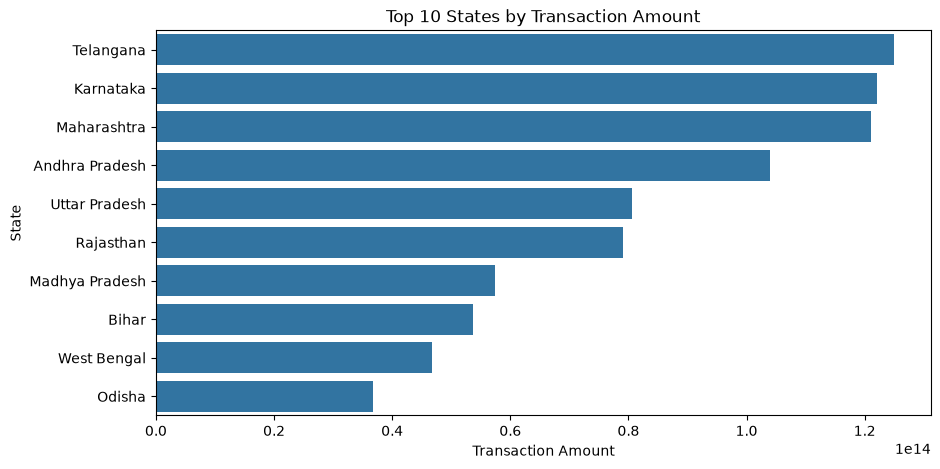

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=market_states,
    x="Total_Amount",
    y="States"
)

plt.title("Top 10 States by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("State")

plt.show()

### Transaction Type Distribution

In [7]:
query = """
SELECT
    Transaction_type,
    SUM(Transaction_amount) AS Total_Amount
FROM aggregated_transaction
GROUP BY Transaction_type
ORDER BY Total_Amount DESC
"""

market_type = pd.read_sql(query, conn)

market_type

C:\Users\Devendra\AppData\Local\Temp\ipykernel_50372\3173841447.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  market_type = pd.read_sql(query, conn)


,Transaction_type,Total_Amount
0,Peer-to-peer payments,799582076912574
1,Merchant payments,196019631223161
2,Recharge & bill payments,40016278079727
3,Others,522841984863
4,Financial Services,426056300469


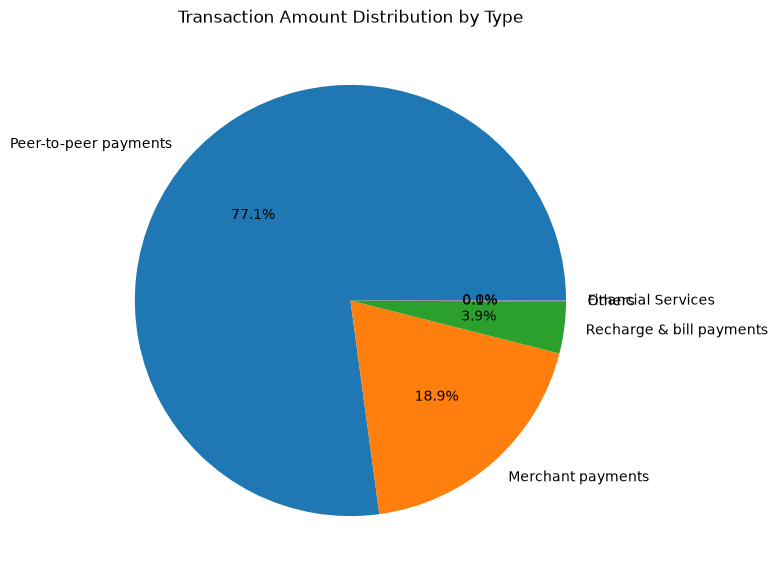

In [8]:
plt.figure(figsize=(7,7))

plt.pie(
    market_type["Total_Amount"],
    labels=market_type["Transaction_type"],
    autopct="%1.1f%%"
)

plt.title("Transaction Amount Distribution by Type")

plt.show()

## Conclusion

The analysis identifies the top-performing states and major
transaction categories.

These insights can help PhonePe identify strong markets,
understand payment preferences, and prioritize regions for
future market expansion.